## Drawing static graphs

![](img/Strichfiguren.jpeg)

---

### Get prepared

#### Installations

#### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import networkx as nx
import json
from networkx.readwrite import json_graph
import math
import subprocess

---

### US Presidential Inauguration Addresses

#### Load USPresInaugAddr_0.14 graph as sample graph

In [2]:
# Reconstruct the graph
with open('graphs/USPresInaugAddr_0.14.json', 'r', encoding='utf-8') as f:
    InaugAddr_json = json.load(f)
X = nx.node_link_graph(InaugAddr_json)
print(X)
print (X.nodes(data=True))

Graph with 153 nodes and 604 edges
[('arrive', {'bipartite': 1, 'term_frq': 5, 'doc_frq': 5, 'degree': 18, 'betweenness': 0.0, 'closeness': 0.11842105263157894, 'used_in': ['02_washington_1793']}), ('ceremony', {'bipartite': 1, 'term_frq': 11, 'doc_frq': 8, 'degree': 18, 'betweenness': 0.0, 'closeness': 0.11842105263157894, 'used_in': ['02_washington_1793']}), ('distinguished', {'bipartite': 1, 'term_frq': 19, 'doc_frq': 14, 'degree': 18, 'betweenness': 0.0, 'closeness': 0.11842105263157894, 'used_in': ['02_washington_1793']}), ('entertain', {'bipartite': 1, 'term_frq': 18, 'doc_frq': 15, 'degree': 18, 'betweenness': 0.0, 'closeness': 0.11842105263157894, 'used_in': ['02_washington_1793']}), ('execution', {'bipartite': 1, 'term_frq': 13, 'doc_frq': 10, 'degree': 18, 'betweenness': 0.0, 'closeness': 0.11842105263157894, 'used_in': ['02_washington_1793']}), ('incur', {'bipartite': 1, 'term_frq': 4, 'doc_frq': 4, 'degree': 18, 'betweenness': 0.0, 'closeness': 0.11842105263157894, 'used_in

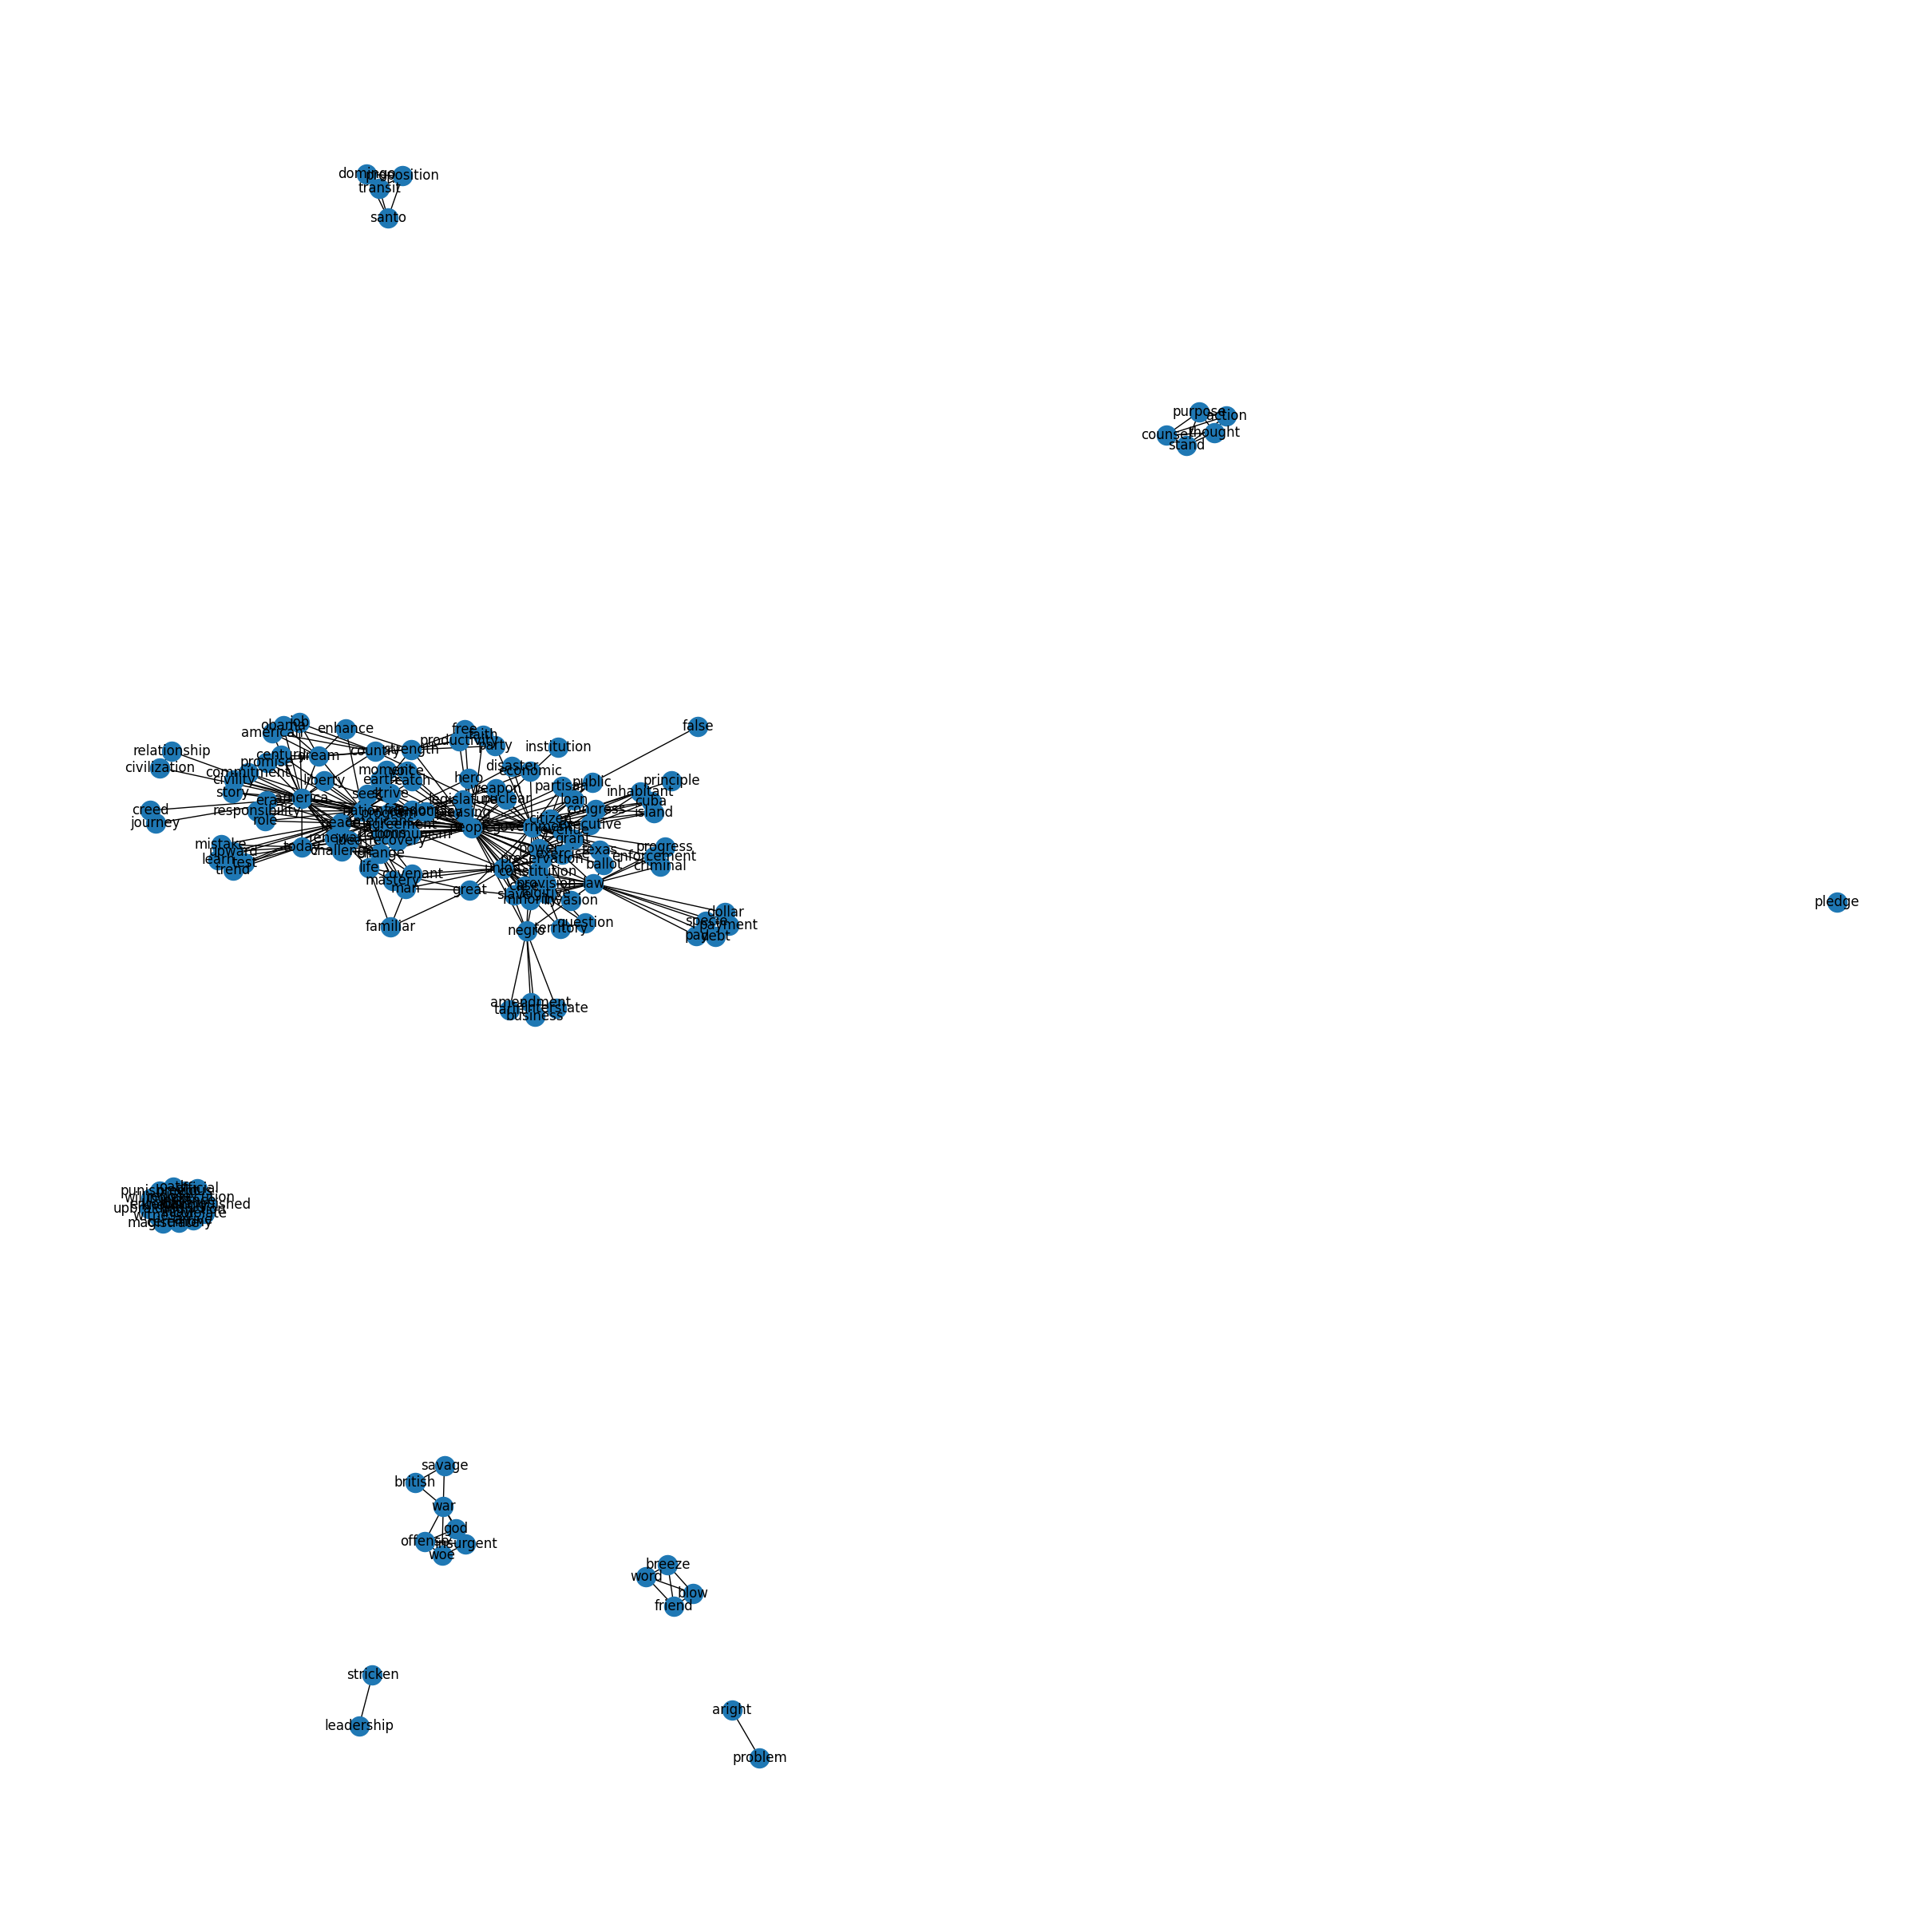

In [3]:
threshold = 0.14
pos = nx.spring_layout(X)
plt.figure(figsize=(24, 24))
nx.draw(X, pos, with_labels=True)   
plt.show()

#### Graphviz

We are now generating a graph visualization with Graphviz. This gives us more freedom in graph styling.

![](img/NetworkX_to_svg.png)

#### Node and edge styling in DOT file

In [4]:
# Functions to compute node attributes

dark = False
directory_path_in = "./misc/"
with open(f"{directory_path_in}meta.json", 'r', encoding='utf-8') as f:
    meta = json.load(f)
    f.close()
#print(meta)

#node_coloring = "node coloring: party"
node_coloring = "node coloring: year"

def computeNodeFillcolor_party(att):
    global dark
    xx = att['used_in']
    y = [meta[x]['party'] for x in xx]
    z = dict(Counter(y))
    if 'Republikaner' in z and 'Demokrat' in z:
        return 'Thistle'
    elif 'Republikaner' in z:
        dark = True
        return '#E9141D'
    elif 'Demokrat' in z:
        dark = True
        return '#0015BC'
    else:
        return 'lightblue'

def computeNodeFillcolor_year(att):
    global dark
    xx = att['used_in']
    ix = xx[0].split('_')
    year = ix[-1]
    #print(year)
    blue2yellow = [('#081d58ff','dark'), ('#253494ff', 'dark'), ('#225ea8ff', 'dark'), ('#1d91c0ff', 'light'), \
                   ('#41b6c4ff', 'light'), ('#7fcdbbff', 'light'), ('#c7e9b4ff', 'light'), ('#edf8b1ff', 'light'), ('#ffffd9ff', 'light')]
    pastell   = [('#fbb4aeff', 'light'), ('#b3cde3ff', 'light'), ('#ccebc5ff', 'light'), ('#decbe4ff', 'light'), \
                 ('#fed9a6ff', 'light'), ('#ffffccff', 'light'), ('#e5d8bdff', 'light'), ('#fddaecff', 'light'), ('#f2f2f2ff', 'light')]
    palette = blue2yellow
    if year == '1789' or year == '1793':  # G. Washington's addresses
        if palette[0][1] == "dark":
            dark = True
        return palette[0][0]
    elif year >  '1793' and year < '1805':
        if palette[1][1] == "dark":
            dark = True
        return palette[1][0]
    elif year >= '1805' and year < '1833':
        if palette[2][1] == "dark":
            dark = True
        return palette[2][0]
    elif year >= '1833' and year < '1866':
        if palette[3][1] == "dark":
            dark = True
        return palette[3][0]
    elif year >= '1866' and year < '1905':
        if palette[4][1] == "dark":
            dark = True
        return palette[4][0]
    elif year >= '1905' and year < '1933':
        if palette[5][1] == "dark":
            dark = True
        return palette[5][0]
    elif year >= '1933' and year < '1965':
        if palette[6][1] == "dark":
            dark = True
        return palette[6][0]
    elif year >= '1965' and year < '2001':
        if palette[7][1] == "dark":
            dark = True
        return palette[7][0]
    elif year >= '2001':
        if palette[8][1] == "dark":
            dark = True
        return palette[8][0]
    else:
        return 'lightblue'
    
def computeNodeFillcolor(att):
    if node_coloring == "node coloring: party":
        return computeNodeFillcolor_party(att)
    else:
        return computeNodeFillcolor_year(att)
    
def computeNodeWidth(att):
    #print(att.get('term_frq'), att.get('id'))
    w  = 1.0 + math.sqrt(0.2*(att.get('term_frq')-1))
    return w

def computeNodeFontcolor():
    global dark
    if dark:
        dark = False
        return 'white'
    else:
        return 'black'
    
def computeNodeTooltip(att):
    xx = str(att['used_in'])
    return xx.replace("[", "").replace("]", "").replace(", ", "\n")

# Functions to compute edge attributes

def computeEdgePenwidth(att):
    return str(att.get('weight')) 

def computeEdgeColor(att):
    if att.get('weight') > 1:
        return 'red'
    else:
        return 'black'

#### Node width formula

<Axes: xlabel='term_freq value', ylabel='node width factor'>

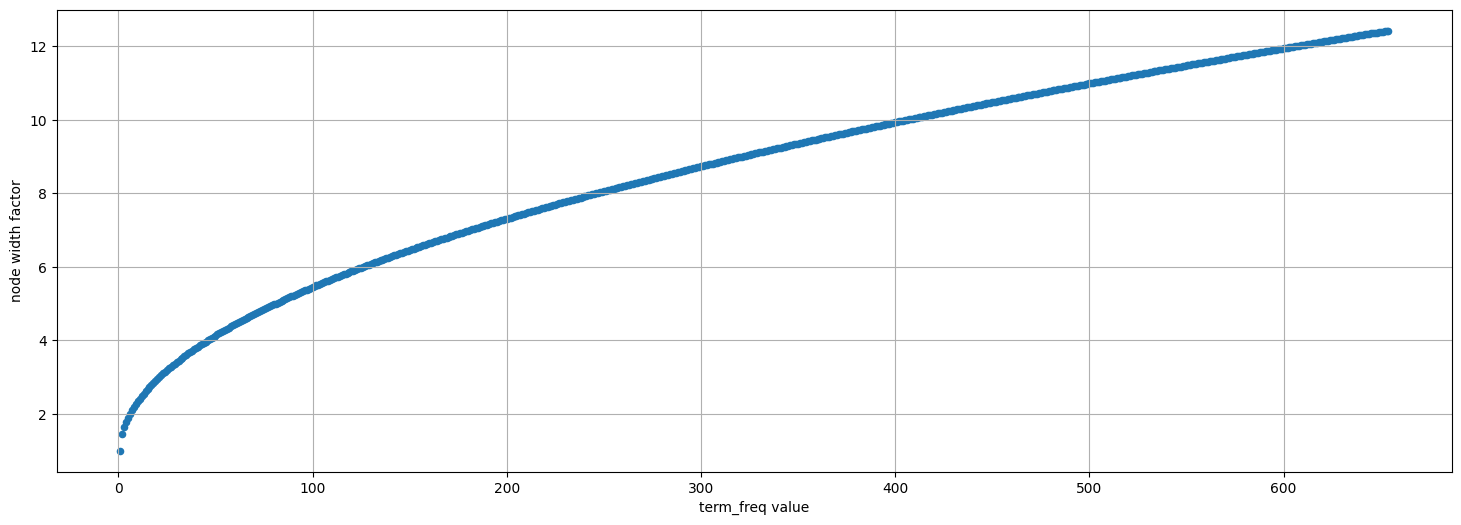

In [12]:
xy = {"x": range (1,655), "y": [1.0 + math.sqrt(0.2*(i-1)) for i in range(1,655)]}
node_width = pd.DataFrame(data=xy)
node_width
node_width.plot(kind="scatter", x="x", y="y", figsize=(18,6), xlabel="term_freq value", ylabel="node width factor", grid=True)

#### Creating DOT file for NetworkX graph (function)

In [5]:
def graphToDot(graph=None, outfile=None):

   # check for invocation errors
   if graph == None:
      print ('Missing graph specification.')
      return
   if outfile == None:
      print ('Missing output file specification.')
      return
   
   lbl_f_string = f'''   label=<<FONT POINT-SIZE="80">Keywords of the US Presidential Inauguration Addresses 1789 - 2017</FONT><BR ALIGN="LEFT"/><BR ALIGN="LEFT"/>
<FONT POINT-SIZE="60">keyword tf-idf score &gt;= {threshold}, {len(X.nodes())} nodes, {len(X.edges())} edges, graph density: {round(nx.density(X),3)*100}%, {node_coloring}</FONT><BR ALIGN="LEFT"/>>'''

   #lbl_f_string = "This is a test \lof creating my lines\lin a non-centeredway\l"
   
   #dot file header
   dot  = 'graph {\n   overlap="prism1000"\n   rankdir="LR"\n   outputorder="edgesfirst"\n'
   dot += '   fontsize="80"\n   fontname="Arial"\n   labelloc="t"\n   labeljust="l"'
   dot +=     lbl_f_string
   dot += '   node [margin=0 fontname="Arial" fontcolor="black" fontsize=64 shape=circle style=filled];\n'

   # edges
   for u,v,att in graph.edges(data=True):
      dot += f'   {u} -- {v} [id="{u}--{v}"'
      dot += f' penwidth={computeEdgePenwidth(att)}'
      dot += f' color="{computeEdgeColor(att)}"]\n'

   #nodes
   for u,att in graph.nodes(data=True):
      dot += f'   {u} [id="{u}"'
      dot += f' fillcolor="{computeNodeFillcolor(att)}"'  
      dot += f' fontcolor="{computeNodeFontcolor()}"' 
      dot += f' width={computeNodeWidth(att)}' 
      dot += f' tooltip="{computeNodeTooltip(att)}"]\n'

   # close dot file
   dot += '}'

   with open(outfile, 'w', encoding = 'utf8') as file:
      file.write(dot)
   return

#### Create SVG file from DOT file

In [12]:
# Generate SVG graph and save it
dot_file = f'graphs/USPresInaugAddr_{threshold}.dot'
svg_file = f'graphs/USPresInaugAddr_{threshold}.svg'
plain_file = f'graphs/USPresInaugAddr_{threshold}.dot.plain'
dot_json_file = f'graphs/USPresInaugAddr_{threshold}.dot.json'
outfile = dot_file
graphToDot(X, outfile)
infile  = outfile
print ('in ', infile)
outfile = svg_file
print ('out', outfile)
sfdp = "C:/Program Files/Graphviz/bin/sfdp.exe"
dot = "C:/Program Files/Graphviz/bin/dot.exe"
subprocess.run ([f"{sfdp}", f"{infile}", '-o', f"{svg_file}", '-Tsvg'])
subprocess.run ([f"{sfdp}", f"{infile}", '-o', f"{dot_json_file}", '-Tjson'])

in  graphs/USPresInaugAddr_0.14.dot
out graphs/USPresInaugAddr_0.14.svg


CompletedProcess(args=['C:/Program Files/Graphviz/bin/sfdp.exe', 'graphs/USPresInaugAddr_0.14.dot', '-o', 'graphs/USPresInaugAddr_0.14.dot.json', '-Tjson'], returncode=0)

#### Create HTML embedding for SVG file

In [27]:
w = 2048
h = 1536
graph_name = f"USPresInaugAddr_{threshold}"

html =  "<!DOCTYPE html>\n  <html>\n    <head>\n    </head>\n    <body>\n      <div style='display: flex; justify-content: center; align-items: center;'>\n"
html += f"        <object data='{graph_name}.svg'  max-width='{w}px'  height='{h}px'>\n"
html += "      </div>\n    </body>\n</html>"
print (html)
with open(f"graphs/{graph_name}.html", "w") as f:
  f.write(html)

<!DOCTYPE html>
  <html>
    <head>
    </head>
    <body>
      <div style='display: flex; justify-content: center; align-items: center;'>
        <object data='USPresInaugAddr_0.14.svg'  max-width='2048px'  height='1536px'>
      </div>
    </body>
</html>


---

### Netflix co-actor graph

#### Load Netflix co-actor graph

In [ ]:
# Reconstruct the graph
with open('graphs/co-actor_graph.json', 'r', encoding='utf-8') as f:
    co_actor_json = json.load(f)
C = nx.node_link_graph(co_actor_json)
print(C)



Graph with 25948 nodes and 185770 edges
